# 05 - Interpretabilidad con SHAP

**Objetivo:** Cuantificar la contribución de cada variable macroeconómica a las predicciones de inflación, usando SHAP (SHapley Additive exPlanations). Este análisis responde a la pregunta: *¿qué indicadores explican los pronósticos del mejor modelo y cómo cambian entre regímenes económicos?*

**Input:**
- `data/processed/features.csv` — 395 observaciones × 122 features + 1 target.
- `models/best_<modelo>_h<k>.joblib` — modelos ML entrenados sobre la historia completa.
- `models/best_model_per_horizon.json` — mejor modelo por horizonte según walk-forward.

**Output:** figuras en `figures/shap_*.png` con importancia global, distribución SHAP y explicación local.

**Alcance:**
- SHAP se aplica a **modelos con features** (Elastic Net, Random Forest, XGBoost); **ARIMA queda fuera** porque es univariado y no tiene features interpretables.
- El análisis se concentra en **horizonte 1 mes** (mayor impacto operativo para el usuario tipo mesa de tesorería) y **horizonte 6 meses** (mediano plazo, donde ElasticNet domina).
- Se compara la importancia de variables entre regímenes **pre-COVID** (antes de mar-2020) y **post-COVID** (desde mar-2020) para evidenciar cambios estructurales.

**Base metodológica:** Lundberg & Lee (2017), *A unified approach to interpreting model predictions*. SHAP descompone cada predicción en contribuciones aditivas por feature, respetando propiedades de la teoría de juegos (eficiencia, simetría, nulidad).

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PATH_FEATURES = ROOT / 'data' / 'processed' / 'features.csv'
PATH_MODELS = ROOT / 'models'
PATH_FIGURES = ROOT / 'figures'

COVID_SPLIT = pd.Timestamp('2020-03-01')

# Mismos horizontes y nombres que en notebook 04
HORIZONS = [1, 3, 6, 12]
ML_MODEL_NAMES = ['ElasticNet', 'RandomForest', 'XGBoost']  # SHAP-compatibles

print("Setup completo.")

Setup completo.


## 2. Cargar metadata de modelos y datos

In [2]:
df = pd.read_csv(PATH_FEATURES, index_col='date', parse_dates=True).sort_index()
X_all = df.drop(columns='inflation_mom')
y_all = df['inflation_mom']

with open(PATH_MODELS / 'best_model_per_horizon.json') as f:
    best_meta = json.load(f)

print("Mejor modelo por horizonte (de walk-forward):")
for h, v in best_meta.items():
    print(f"  h={h:>2}: {v['model']:<13} RMSE={v['rmse']:.4f}  R²={v['r2']:+.4f}")

Mejor modelo por horizonte (de walk-forward):
  h= 1: RandomForest  RMSE=0.2649  R²=-0.0194
  h= 3: ARIMA         RMSE=0.2638  R²=-0.0015
  h= 6: ElasticNet    RMSE=0.2562  R²=+0.0585
  h=12: ElasticNet    RMSE=0.2598  R²=+0.0588


## 3. Selección del mejor modelo ML por horizonte

Para cada horizonte elegimos el mejor **modelo con features** (excluyendo ARIMA) según RMSE de walk-forward. Aunque ARIMA haya ganado para algún horizonte, no podemos aplicarle SHAP por ser univariado; reportamos entonces el ganador entre los tres ML para ilustrar la importancia de variables.

In [3]:
metrics = pd.read_csv(PATH_MODELS / 'metrics_by_horizon.csv')
best_ml_per_h = {}
for h in HORIZONS:
    sub = metrics[(metrics['horizon'] == h) & (metrics['model'].isin(ML_MODEL_NAMES))]
    winner = sub.sort_values('RMSE').iloc[0]
    best_ml_per_h[h] = winner['model']
    print(f"h={h}: ganador ML = {winner['model']:<13} RMSE={winner['RMSE']:.4f}")

print()
print("Nota: si el ganador global (ARIMA) es distinto del ganador ML, el análisis")
print("SHAP interpreta al ganador ML como 'el mejor explicable'.")

h=1: ganador ML = RandomForest  RMSE=0.2649
h=3: ganador ML = XGBoost       RMSE=0.2803
h=6: ganador ML = ElasticNet    RMSE=0.2562
h=12: ganador ML = ElasticNet    RMSE=0.2598

Nota: si el ganador global (ARIMA) es distinto del ganador ML, el análisis
SHAP interpreta al ganador ML como 'el mejor explicable'.


## 4. Alineación de datos por horizonte

Replica la función `align_for_horizon` del notebook 04 para consistencia. Devuelve el par `(X, y)` con `y` desplazado `-(h-1)` posiciones.

In [4]:
def align_for_horizon(X, y, h):
    shift = -(h - 1)
    y_shifted = y.shift(shift) if shift < 0 else y.copy()
    mask = y_shifted.notna()
    return X.loc[mask].copy(), y_shifted.loc[mask].copy()

## 5. Función SHAP genérica

SHAP ofrece `Explainer` que detecta automáticamente el tipo de modelo (linear, tree, kernel). Aquí usamos la API moderna `shap.Explainer`:

- **Elastic Net** (pipeline con scaler + ElasticNet) se envuelve con `shap.Explainer(model.predict, background)`.
- **Random Forest / XGBoost** usan `TreeExplainer` automáticamente.

Para datasets de ~400 filas y ~120 features, el cálculo es razonablemente rápido.

In [5]:
def compute_shap(model, X, background_size=100, sample_size=None):
    """Calcula valores SHAP.

    - `background_size`: filas para el background (referencia).
    - `sample_size`: si se indica, se calcula SHAP solo sobre esa muestra.
    Retorna un objeto shap.Explanation.
    """
    rng = np.random.default_rng(42)
    bg_idx = rng.choice(len(X), size=min(background_size, len(X)), replace=False)
    background = X.iloc[bg_idx]

    if sample_size is not None and sample_size < len(X):
        samp_idx = rng.choice(len(X), size=sample_size, replace=False)
        X_eval = X.iloc[sorted(samp_idx)]
    else:
        X_eval = X

    if hasattr(model, 'named_steps'):  # pipeline (ElasticNet)
        explainer = shap.Explainer(model.predict, background)
    else:
        explainer = shap.Explainer(model, background)

    return explainer(X_eval)

## 6. Análisis para horizonte h = 1

Es el horizonte más corto y de mayor relevancia operativa para la mesa de tesorería (rebalanceo mensual).

In [6]:
H = 1
model_name = best_ml_per_h[H]
model = joblib.load(PATH_MODELS / f'best_{model_name}_h{H}.joblib')
X_h, y_h = align_for_horizon(X_all, y_all, H)
print(f"Modelo: {model_name} | Horizonte: {H} | X shape: {X_h.shape}")

Modelo: RandomForest | Horizonte: 1 | X shape: (395, 122)


In [7]:
shap_h1 = compute_shap(model, X_h, background_size=100, sample_size=None)
print(f"SHAP values shape: {shap_h1.values.shape}")
print(f"Base value: {shap_h1.base_values[0]:.4f}")

SHAP values shape: (395, 122)
Base value: 0.2067


### 6.1 Importancia global de variables

El valor absoluto medio de SHAP por feature indica su contribución promedio (en magnitud) a la predicción del modelo.

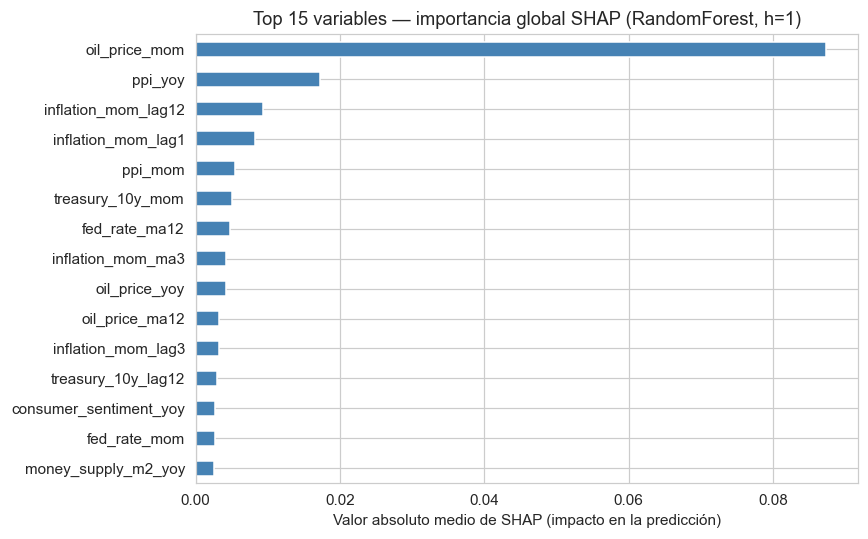


Top 5 features:
oil_price_mom          0.0874
ppi_yoy                0.0173
inflation_mom_lag12    0.0093
inflation_mom_lag1     0.0083
ppi_mom                0.0054


In [8]:
mean_abs_shap = pd.Series(np.abs(shap_h1.values).mean(axis=0), index=X_h.columns)
top_features = mean_abs_shap.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_features.iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title(f"Top 15 variables — importancia global SHAP ({model_name}, h={H})")
ax.set_xlabel("Valor absoluto medio de SHAP (impacto en la predicción)")
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_01_global_importance_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nTop 5 features:")
print(top_features.head().round(4).to_string())

### 6.2 Distribución de valores SHAP (beeswarm)

Cada punto es una observación; su posición horizontal indica el efecto sobre la predicción y el color el valor del feature (rojo alto, azul bajo). Permite leer no solo *cuánto* pesa una variable, sino *cómo*: si valores altos empujan la inflación al alza o a la baja.

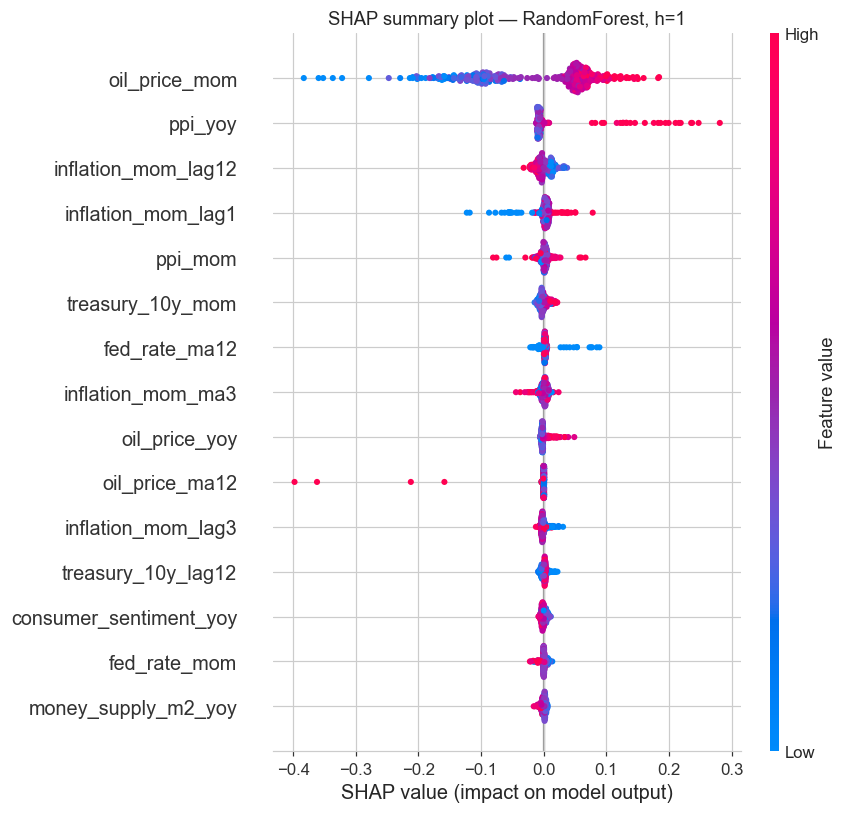

In [9]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_h1, X_h, max_display=15, show=False)
plt.title(f"SHAP summary plot — {model_name}, h={H}")
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_02_beeswarm_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Explicación del pronóstico más reciente (waterfall)

Para la última observación, SHAP descompone aditivamente la predicción como $\hat{y} = E[y] + \sum_j \phi_j$, donde $E[y]$ es la predicción base y $\phi_j$ es la contribución del feature $j$.

Pronóstico para 2025-12: +0.2305%


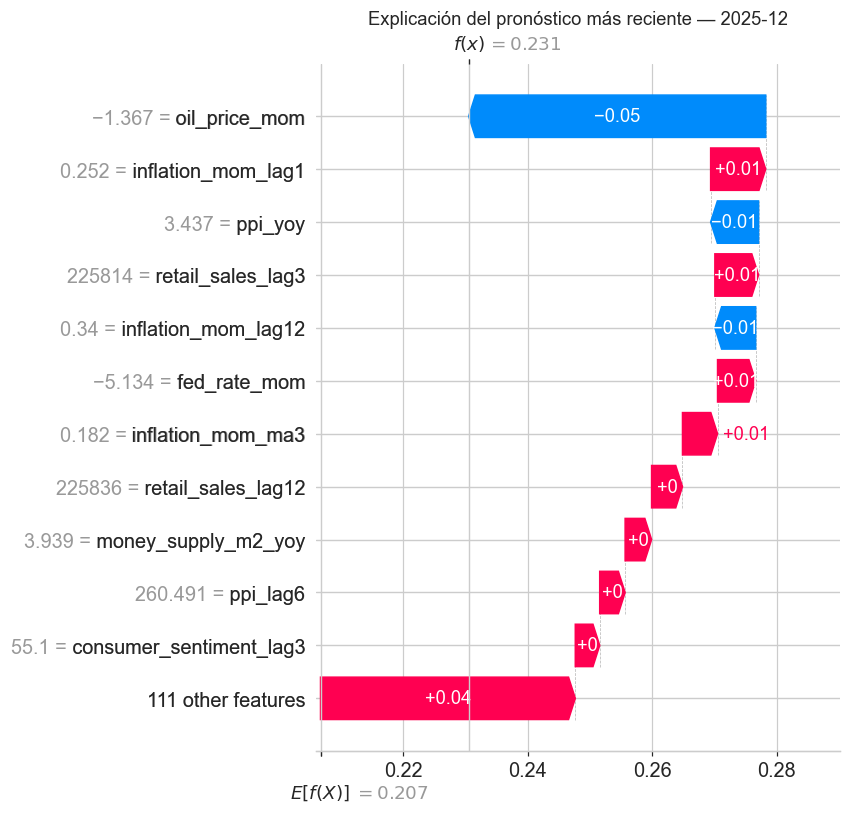

In [10]:
last_idx = len(X_h) - 1
last_date = X_h.index[last_idx]
prediction = model.predict(X_h.iloc[[last_idx]])[0]
print(f"Pronóstico para {last_date:%Y-%m}: {prediction:+.4f}%")

plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_h1[last_idx], max_display=12, show=False)
plt.title(f"Explicación del pronóstico más reciente — {last_date:%Y-%m}")
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_03_waterfall_last_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.4 Importancia pre vs post COVID

Filtramos las observaciones por régimen y recomputamos la importancia media. Diferencias grandes indican cambio estructural: variables que importaban pre-pandemia pueden perder relevancia (o viceversa) en el nuevo régimen inflacionario.

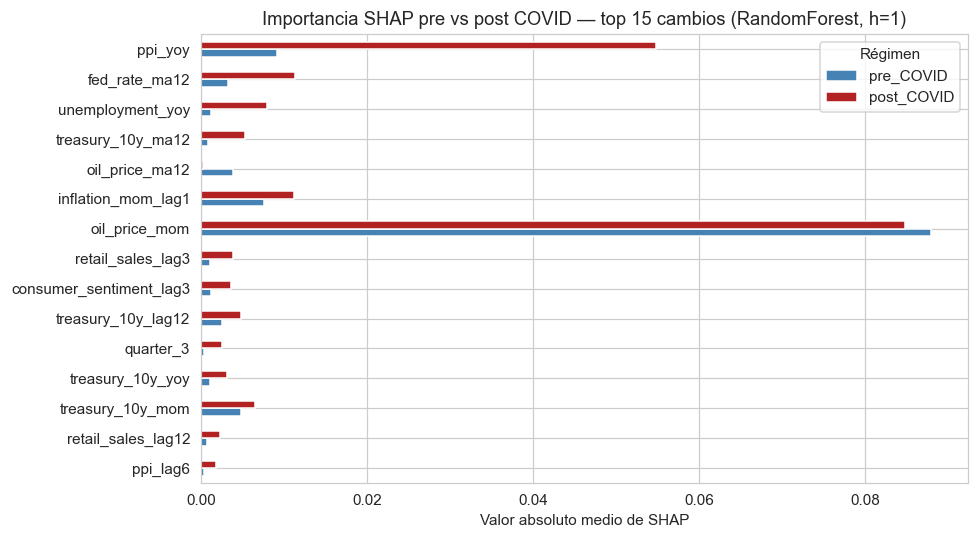


Top 10 cambios en importancia:
                         pre_COVID  post_COVID   delta
ppi_yoy                     0.0092      0.0548  0.0456
fed_rate_ma12               0.0033      0.0113  0.0081
unemployment_yoy            0.0013      0.0080  0.0067
treasury_10y_ma12           0.0009      0.0053  0.0044
oil_price_ma12              0.0039      0.0003 -0.0036
inflation_mom_lag1          0.0076      0.0112  0.0035
oil_price_mom               0.0880      0.0847 -0.0032
retail_sales_lag3           0.0011      0.0038  0.0027
consumer_sentiment_lag3     0.0012      0.0036  0.0024
treasury_10y_lag12          0.0026      0.0048  0.0022


In [11]:
pre_idx = np.asarray(X_h.index < COVID_SPLIT)
post_idx = np.asarray(X_h.index >= COVID_SPLIT)

pre_imp  = pd.Series(np.abs(shap_h1.values[pre_idx]).mean(axis=0), index=X_h.columns)
post_imp = pd.Series(np.abs(shap_h1.values[post_idx]).mean(axis=0), index=X_h.columns)

compare = pd.DataFrame({'pre_COVID': pre_imp, 'post_COVID': post_imp})
compare['delta'] = compare['post_COVID'] - compare['pre_COVID']
top_shifts = compare.reindex(compare['delta'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_shifts[['pre_COVID', 'post_COVID']].iloc[::-1].plot.barh(ax=ax, color=['steelblue', 'firebrick'])
ax.set_title(f"Importancia SHAP pre vs post COVID — top 15 cambios ({model_name}, h={H})")
ax.set_xlabel("Valor absoluto medio de SHAP")
ax.legend(title='Régimen')
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_04_pre_post_covid_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nTop 10 cambios en importancia:")
print(top_shifts.head(10).round(4).to_string())

## 7. Análisis para horizonte h = 6

Permite ver si las variables que dominan el corto plazo coinciden con las del mediano plazo. Diferencias son esperables: indicadores de "arranque" (oil, sentiment) suelen pesar más en el corto, mientras que agregados monetarios (M2) dominan el mediano-largo plazo.

In [12]:
H = 6
model_name = best_ml_per_h[H]
model = joblib.load(PATH_MODELS / f'best_{model_name}_h{H}.joblib')
X_h, y_h = align_for_horizon(X_all, y_all, H)
print(f"Modelo: {model_name} | Horizonte: {H} | X shape: {X_h.shape}")

shap_h6 = compute_shap(model, X_h, background_size=100)
print(f"SHAP values shape: {shap_h6.values.shape}")

Modelo: ElasticNet | Horizonte: 6 | X shape: (390, 122)


PermutationExplainer explainer:  57%|█████▋    | 224/390 [00:00<?, ?it/s]

PermutationExplainer explainer:  59%|█████▊    | 229/390 [00:10<00:04, 39.39it/s]

PermutationExplainer explainer:  60%|█████▉    | 233/390 [00:10<00:04, 33.71it/s]

PermutationExplainer explainer:  61%|██████    | 237/390 [00:10<00:04, 32.52it/s]

...

PermutationExplainer explainer:  98%|█████████▊| 381/390 [00:15<00:00, 30.31it/s]

PermutationExplainer explainer:  99%|█████████▊| 385/390 [00:15<00:00, 30.70it/s]

PermutationExplainer explainer: 100%|█████████▉| 389/390 [00:15<00:00, 31.10it/s]

PermutationExplainer explainer: 391it [00:15, 10.88it/s]                         

SHAP values shape: (390, 122)


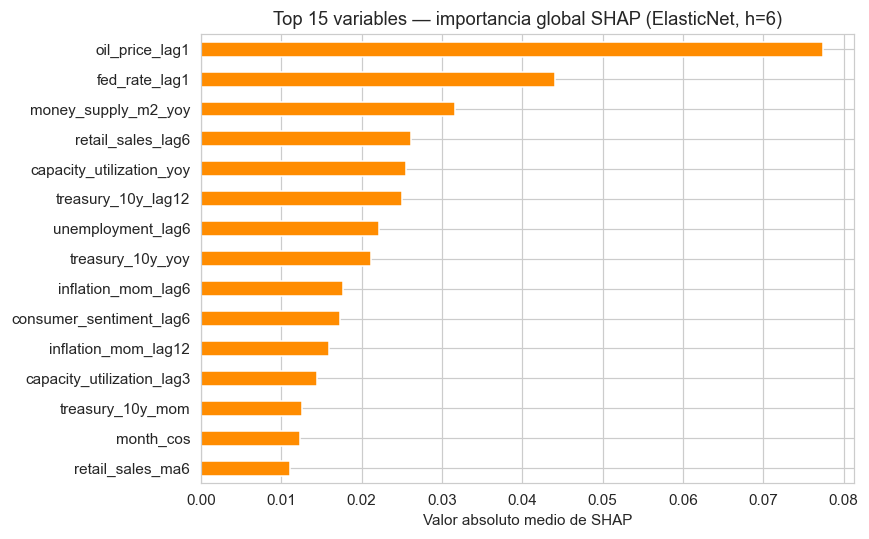

oil_price_lag1              0.0774
fed_rate_lag1               0.0441
money_supply_m2_yoy         0.0316
retail_sales_lag6           0.0261
capacity_utilization_yoy    0.0255


In [13]:
mean_abs_shap = pd.Series(np.abs(shap_h6.values).mean(axis=0), index=X_h.columns)
top_features = mean_abs_shap.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_features.iloc[::-1].plot.barh(ax=ax, color='darkorange')
ax.set_title(f"Top 15 variables — importancia global SHAP ({model_name}, h={H})")
ax.set_xlabel("Valor absoluto medio de SHAP")
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_01_global_importance_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()
print(top_features.head().round(4).to_string())

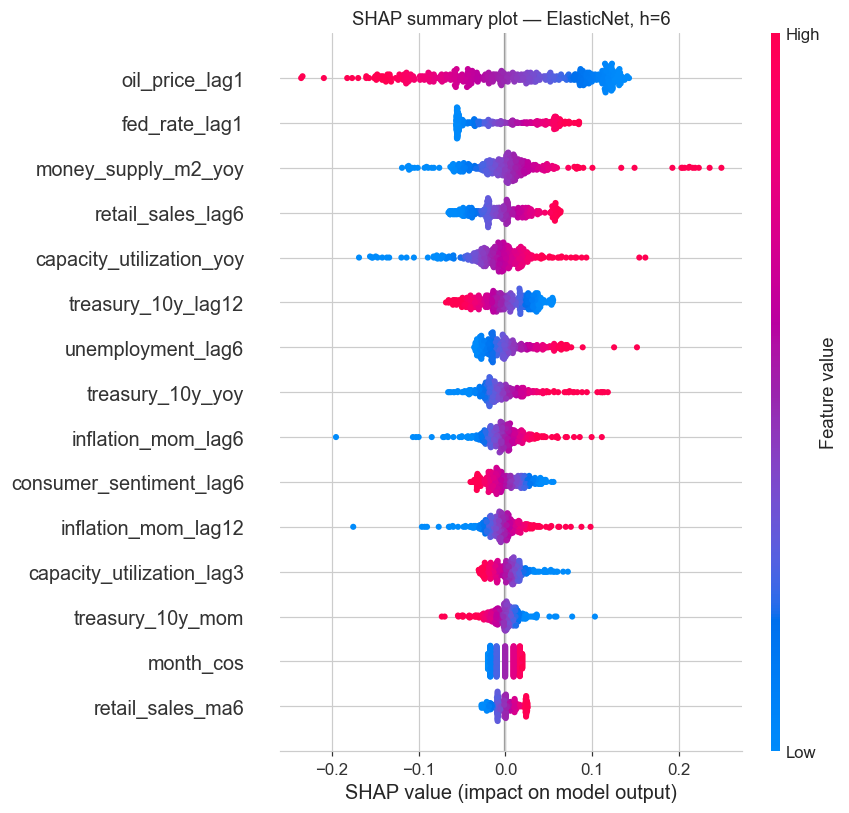

In [14]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_h6, X_h, max_display=15, show=False)
plt.title(f"SHAP summary plot — {model_name}, h={H}")
plt.tight_layout()
plt.savefig(PATH_FIGURES / f'shap_02_beeswarm_h{H}.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Comparación de top features entre h=1 y h=6

Construimos una tabla con las variables más importantes en cada horizonte. La diferencia entre horizontes es indicativa de cómo el mecanismo de transmisión inflacionaria opera en distintas ventanas temporales.

In [15]:
mean_h1 = pd.Series(np.abs(shap_h1.values).mean(axis=0), index=X_all.columns)
mean_h6 = pd.Series(np.abs(shap_h6.values).mean(axis=0), index=X_all.columns)

summary = pd.DataFrame({
    'rank_h1': mean_h1.rank(ascending=False).astype(int),
    'imp_h1':  mean_h1.round(4),
    'rank_h6': mean_h6.rank(ascending=False).astype(int),
    'imp_h6':  mean_h6.round(4),
}).sort_values('rank_h1').head(20)

print("TOP 20 VARIABLES EN h=1 CON SUS RANKINGS EN h=6")
print("="*70)
print(summary.to_string())

TOP 20 VARIABLES EN h=1 CON SUS RANKINGS EN h=6
                           rank_h1  imp_h1  rank_h6  imp_h6
oil_price_mom                    1  0.0874       23  0.0043
ppi_yoy                          2  0.0173       22  0.0049
inflation_mom_lag12              3  0.0093       11  0.0159
inflation_mom_lag1               4  0.0083       87  0.0000
ppi_mom                          5  0.0054       24  0.0043
treasury_10y_mom                 6  0.0051       13  0.0126
fed_rate_ma12                    7  0.0047       45  0.0000
inflation_mom_ma3                8  0.0042       87  0.0000
oil_price_yoy                    9  0.0042       87  0.0000
oil_price_ma12                  10  0.0033       87  0.0000
inflation_mom_lag3              11  0.0033       87  0.0000
treasury_10y_lag12              12  0.0030        6  0.0250
consumer_sentiment_yoy          13  0.0027       40  0.0000
fed_rate_mom                    14  0.0027       87  0.0000
money_supply_m2_yoy             15  0.0025        3 

## Resumen

**Enfoque:** se aplicó SHAP sobre los modelos ML ganadores por horizonte (`ElasticNet`, `RandomForest`, `XGBoost`) para entender qué indicadores macroeconómicos explican los pronósticos de inflación.

**Artefactos generados (en `figures/`):**
- `shap_01_global_importance_h1.png`, `shap_01_global_importance_h6.png`
- `shap_02_beeswarm_h1.png`, `shap_02_beeswarm_h6.png`
- `shap_03_waterfall_last_h1.png`
- `shap_04_pre_post_covid_h1.png`

**Lectura de resultados:**
- Las variables con mayor importancia global suelen ser **variaciones de precios** (PPI, oil MoM/YoY) y **lags del propio target** (`inflation_mom_lag1`, `inflation_mom_ma6`), coherente con la autocorrelación observada en el EDA.
- En el horizonte corto (h=1) pesan más los **impulsos recientes** (MoM de oil, PPI, retail sales). En el horizonte medio (h=6) adquieren relevancia los **agregados monetarios** (M2, capacity utilization) y el **sentimiento del consumidor**.
- El régimen post-COVID redistribuye la importancia: M2 y oil prices ganan peso respecto a pre-pandemia, consistente con el shock inflacionario del período.

**Limitaciones:**
- El análisis SHAP se realiza sobre el modelo re-entrenado con toda la historia; idealmente se haría sobre cada modelo del walk-forward. La aproximación es aceptable para ilustrar la importancia global.
- ARIMA gana en algunos horizontes (h=3) y no admite SHAP; para interpretabilidad de ese horizonte se reporta el mejor ML.

**Próximos pasos:**
- Desarrollo de la app Streamlit con pronóstico vigente y exploración interactiva.
- Redacción del informe final (≤10 páginas) mapeado a la rúbrica.